# Character Creation Graph Visualization

`agents/character_creation/graph.py`의 컴파일된 LangGraph를 그대로 그려본다.
코드와 다이어그램이 항상 동기화된다 (수동 mermaid 파일과 달리).


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from agents.character_creation.graph import build_graph

graph = build_graph()
print(graph)

/Users/jpaper/Documents/projects/mongle-village/.venv/lib/python3.14/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 1. Mermaid 소스 출력

외부 의존성 없이 항상 동작. 결과 문자열을 https://mermaid.live 에 붙여넣으면 렌더링됨.


In [2]:
mermaid_src = graph.get_graph().draw_mermaid()
print(mermaid_src)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate(validate)
	llm_persona(llm_persona)
	source_upload(source_upload)
	vlm_analyzer(vlm_analyzer)
	image_generator(image_generator)
	generated_upload(generated_upload)
	builder(builder)
	cleanup_source_image(cleanup_source_image)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate;
	cleanup_source_image --> __end__;
	llm_persona --> image_generator;
	source_upload --> vlm_analyzer;
	vlm_analyzer --> image_generator;
	validate -.-> llm_persona;
	validate -.-> source_upload;
	validate -.-> vlm_analyzer;
	image_generator -.-> generated_upload;
	image_generator -.-> cleanup_source_image;
	generated_upload -.-> builder;
	generated_upload -.-> cleanup_source_image;
	builder -.-> cleanup_source_image;
	builder -.-> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 2. Mermaid PNG 인라인 렌더링

mermaid.ink 공개 API를 호출해 PNG를 받아 노트북에 표시.
**인터넷 연결 필요.** 차단된 환경이면 셀 3으로 넘어갈 것.


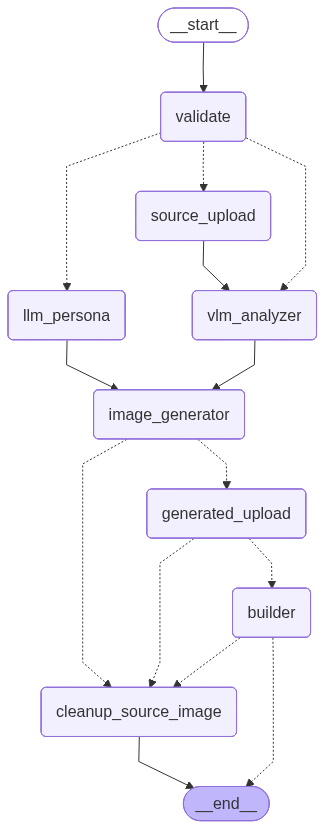

In [3]:
from IPython.display import Image, display

try:
    png_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
except Exception as exc:
    print(f"PNG 렌더링 실패: {exc!r}")
    print("→ 인터넷 차단 또는 mermaid.ink 응답 오류. 셀 1의 텍스트 출력을 사용하세요.")

## 3. 노드/엣지 원본 데이터 확인

어떤 노드/엣지가 등록되었는지 직접 확인 — graph.py 수정 후 검증용.


In [5]:
g = graph.get_graph()

print("=== Nodes ===")
for node_id in g.nodes:
    print(f"  - {node_id}")

print("\n=== Edges ===")
for edge in g.edges:
    cond = " [conditional]" if edge.conditional else ""
    label = f" ({edge.data})" if edge.data else ""
    print(f"  - {edge.source} → {edge.target}{cond}{label}")

=== Nodes ===
  - __start__
  - validate
  - llm_persona
  - source_upload
  - vlm_analyzer
  - image_generator
  - generated_upload
  - builder
  - cleanup_source_image
  - __end__

=== Edges ===
  - __start__ → validate
  - cleanup_source_image → __end__
  - llm_persona → image_generator
  - source_upload → vlm_analyzer
  - vlm_analyzer → image_generator
  - validate → llm_persona [conditional]
  - validate → source_upload [conditional]
  - validate → vlm_analyzer [conditional]
  - image_generator → generated_upload [conditional]
  - image_generator → cleanup_source_image [conditional]
  - generated_upload → builder [conditional]
  - generated_upload → cleanup_source_image [conditional]
  - builder → cleanup_source_image [conditional]
  - builder → __end__ [conditional]
